In [55]:
import glob
import os
import numpy as np
import pandas as pd
import scipy.signal
import skimage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu

plt.style.use('styleNB.mplstyle')


def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell', 'position']):
        d_ = d_.copy().sort_values('interval')
        interval_frames = d_.interval.values[::frame_step]
        sampled = d_[d_['interval'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    return df_out

# Load in data

In [10]:
df_1 = pd.read_csv('../../data/processed_2D_tracking/20250406_isolated_zebrafish_keratocytes_tracking_filtered.csv')
df_2 = pd.read_csv('../../data/processed_2D_tracking/20250420_isolated_zebrafish_keratocytes_tracking_filtered.csv')
df = pd.concat([df_1, df_2], ignore_index=True)
df = df[df.E_V_cm != 5]

# Step 1: unit correction
## Note that videos were tracked in units of pixels. Conversion factors:
# Rio scope (AP samples): 1.547 pixels/um
# Oslo scope (NB samples): 1.530 pixel/um

# Make a copy to avoid modifying the original DataFrame in-place (optional but safe)
df_converted = df.copy()

# Apply conversion factor: NB = 1.53, AP = 1.547
df_converted.loc[df_converted['user'] == 'NB', ['x', 'y']] /= 1.53
df_converted.loc[df_converted['user'] == 'AP', ['x', 'y']] /= 1.547
df_converted['celltype'] = df_converted['celltype_genotype']
df = df_converted

df = df[df.E_V_cm != 5]

df.head()

,Unnamed: 0,cell,frame,x,y,z,celltype,position,E_V_cm,date,trial,user,celltype_genotype
0,0,0,0,349.024110,196.442253,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
1,1,0,1,359.114003,194.286702,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
2,2,0,2,369.991581,196.799344,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
3,3,0,3,380.458097,202.806752,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT
4,4,0,4,383.005824,214.212646,0.0,Galvanin_WT,2,0,20250403,0,AP,Galvanin_WT


In [11]:

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype_genotype', 'E_V_cm', 'date', 'trial', 'user', 'cell', 'position']):
    frames = sorted(d_.frame.unique())
    
    # Filter: skip short tracks
    if len(frames) <= 10:
        continue

    min_frame = min(frames)
    d_ = d_.copy()
    d_['rel_frame'] = d_.frame - min_frame

    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)  # full resolution

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])
    
    positions = np.array(positions)
    if np.isnan(positions).any():
        continue

    # # Filter: ignore any non-moving cells 
    total_movement = np.sum(np.sqrt(np.sum(np.diff(positions, axis=0)**2, axis=1)))
    if total_movement < 20:
        continue

    # Keep untrimmed full-resolution track
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'position': g[-1],
            'interval': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)    

df_filtered_tracks['frame'] = df_filtered_tracks['interval']



# Plotting

## Trajectories

('Galvanin_KO', 0)
('Galvanin_KO', 1)
('Galvanin_KO', 3)
('Galvanin_WT', 0)
('Galvanin_WT', 1)
('Galvanin_WT', 3)


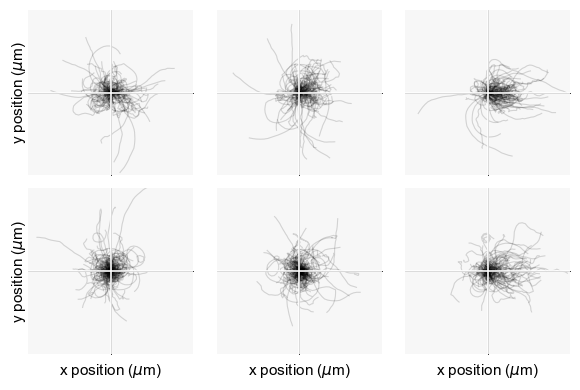

In [56]:
f, ax = plt.subplots(2, 3, figsize=(6, 4))
EF_dict = {0: 0, 1: 1, 3: 2}
dict_ax = {'Galvanin_WT': 0, 'Galvanin_KO': 1}


for g, d in df_filtered_tracks.groupby(['celltype', 'E_V_cm']):
    print(g)
    trajectories = []
    count_cell = 0
    for i, d_ in d.groupby(['cell', 'trial', 'date', 'user', 'position']):
        if len(d_) < 5:
            continue
        if count_cell > 126:
            continue


        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]
        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)

        # Optional: mark final point faintly
        #ax_.scatter(x_rel[-1], y_rel[-1], s=2, color='black', alpha=0.1, zorder=5)

        count_cell += 1

    ax_ = ax[dict_ax[g[0]], EF_dict[g[1]]]

    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    ax_.set_xlim(-400, 400)
    ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    ax_.set_xlabel(r'x position ($\mu$m)')
    ax_.set_ylabel(r'y position ($\mu$m)')

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Hide x labels if not in bottom row
        if r < n_rows - 1:
            ax_.set_xlabel('')
            ax_.tick_params(labelbottom=False)

        # Hide y labels if not in leftmost column
        if c > 0:
            ax_.set_ylabel('')
            ax_.tick_params(labelleft=False)

n_rows, n_cols = ax.shape

for r in range(n_rows):
    for c in range(n_cols):
        ax_ = ax[r, c]

        # Keep axis labels only on outer left and bottom
        if r < n_rows - 1:
            ax_.set_xlabel('')
        if c > 0:
            ax_.set_ylabel('')

        # Remove all tick labels
        ax_.set_xticklabels([])
        ax_.set_yticklabels([])

        # Optional: reduce tick mark length
        ax_.tick_params(length=0)
            
plt.tight_layout()
f.savefig('../../figures/20250523_zebrafish_tracks.pdf', bbox_inches='tight')

## Speed

In [13]:
# df_intervals_1 = parse_trajectories(df_filtered_tracks, frame_step=1)
# df_intervals_2 = parse_trajectories(df_filtered_tracks, frame_step=2)
# df_intervals_3 = parse_trajectories(df_filtered_tracks, frame_step=3)
# df_intervals_5 = parse_trajectories(df_filtered_tracks, frame_step=5)

# Step 1: Define interval (number of frames between points)
interval = 2

# Step 2: subsample
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)

colors = sns.color_palette("tab10")
color_dict = dict(zip(['Galvanin_WT', 'Galvanin_KO','',''
                       , ''], colors))  

color_dict.update({'Galvanin_WT':'#B8BABC'})


# Plot directed speed along x-axis
colors = sns.color_palette("tab10")
color_dict = {
    'Galvanin_WT': '#B8BABC',
    'Galvanin_KO': colors[1],
    '': colors[2]  
}


0 V/cm
  Galvanin_KO: 2 cells, mean 0.1932
  Galvanin_KO: 13 cells, mean 0.1276
  Galvanin_KO: 2 cells, mean 0.1326
  Galvanin_KO: 4 cells, mean 0.1258
  Galvanin_KO: 18 cells, mean 0.0987
  Galvanin_KO: 3 cells, mean 0.1978
  Galvanin_KO: 2 cells, mean 0.0962
  Galvanin_KO: 6 cells, mean 0.1472
  Galvanin_KO: 1 cells, mean 0.0420
  Galvanin_KO: 6 cells, mean 0.1040
  Galvanin_KO: 7 cells, mean 0.1910
  Galvanin_KO: 4 cells, mean 0.1870
  Galvanin_KO: 6 cells, mean 0.1484
  Galvanin_KO: 2 cells, mean 0.2145
  Galvanin_KO: 11 cells, mean 0.1809
  Galvanin_KO: 8 cells, mean 0.1597
  Galvanin_KO: 11 cells, mean 0.1517
  Galvanin_KO: 5 cells, mean 0.1885
  Galvanin_KO: 4 cells, mean 0.1553
  Galvanin_KO: 23 cells, mean 0.1474
  Galvanin_KO: 4 cells, mean 0.1160
  Galvanin_KO: 18 cells, mean 0.1521
  Galvanin_KO: 4 cells, mean 0.1710
  Galvanin_KO: 6 cells, mean 0.1996
  Galvanin_KO: 4 cells, mean 0.0943
  Galvanin_KO: 3 cells, mean 0.1274
  Galvanin_KO: 16 cells, mean 0.1352
  Galvanin_KO

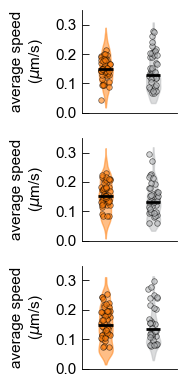

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(2, 4))

celltypes = sorted(df_intervals['celltype'].unique())
celltype_dict = dict(zip(celltypes, np.arange(len(celltypes))))
field_strengths = sorted(df_intervals['E_V_cm'].unique())
field_strengths = [e for e in field_strengths] 

for ax_idx, E in enumerate(field_strengths):
    df_E = df_intervals[df_intervals.E_V_cm == E]
    print(f"\n{E} V/cm")

    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict[celltype]
        speed_all = []

        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user', 'position'], sort=False):
            speed_prep = []

            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue

                d = d.sort_values('interval')
                # Use 2D or 3D displacement depending on z availability
                use_z = 'z' in d.columns and not d['z'].isnull().all()
                pos_cols = ['x', 'y', 'z'] if use_z else ['x', 'y']
                pos = d[pos_cols].values

                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / (interval * 60)  # μm/sec
                

                if len(speeds) > 0:
                    speed_prep.append(np.mean(speeds))
            # print(speed_prep)

            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax[ax_idx].errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=5
                )
                speed_all.extend(speed_prep)
                print(f"  {celltype}: {len(speed_prep)} cells, mean {np.mean(speed_prep):.4f}")

        # Plot violin if there’s data
        if len(speed_all) > 0:
            vp = ax[ax_idx].violinplot(
                speed_all, positions=[ind], points=60, widths=0.3,
                showmeans=False, showextrema=False, showmedians=False,
                bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

            ax[ax_idx].hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                              color='k', lw=2, zorder=10)

# Style all axes
for a in ax:
    a.set_xlim(-0.5, len(celltypes) - 0.5)
    a.set_ylim(0, 0.35)
    a.set_yticks([0.0, 0.1, 0.2, 0.3])
    a.set_ylabel('average speed\n' + r'($\mu$m/s)')
    a.xaxis.set_visible(False)

plt.tight_layout()

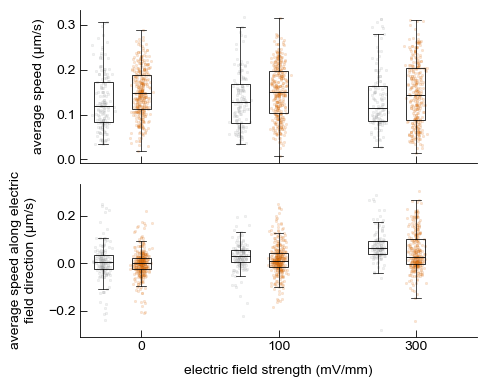

In [28]:
displacement_records_mag = []
displacement_records_proj = []

for (celltype, E), df_ct_E in df_intervals.groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell, position), d in df_ct_E.groupby(['date', 'trial', 'user', 'cell', 'position']):
        if len(d) <= 1:
            continue
        d = d.sort_values('interval')

        dx = np.diff(d['x'].values)
        dy = np.diff(d['y'].values)

        dists = np.sqrt(dx**2 + dy**2)
        mean_speed = np.mean(dists) / (interval * 60)

        mean_dx = np.mean(dx)
        mean_proj_speed = mean_dx / (interval * 60)

        displacement_records_mag.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'position': position,
            'mean_speed': mean_speed
        })
        displacement_records_proj.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'position': position,
            'mean_speed': mean_proj_speed
        })

df_mag_plot = pd.DataFrame(displacement_records_mag)
df_proj_plot = pd.DataFrame(displacement_records_proj)





fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5, 4), sharex=True)

E_levels = sorted(df_mag_plot['E_V_cm'].unique())
celltypes = ['Galvanin_WT', 'Galvanin_KO']
colors = [color_dict[ct] for ct in celltypes]
celltype_color_dict = dict(zip(celltypes, colors))

group_spacing = 0.9
dodge_offset = 0.25
jitter_scale = 0.025
box_width = 0.125
titles = ["average speed (μm/s)", "average speed along electric\nfield direction (μm/s)"]
datasets = [df_mag_plot, df_proj_plot]

for row, (ax, df_plot, ylabel) in enumerate(zip(axs, datasets, titles)):
    for i, E in enumerate(E_levels):
        x_base = i * group_spacing
        for j, celltype in enumerate(celltypes):
            x_pos = x_base + (j - 1) * dodge_offset
            df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
            speeds = df_subset['mean_speed'].values

            if len(speeds) == 0:
                continue

            # Boxplot
            ax.boxplot(
                [speeds],
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showcaps=True,
                showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=.56),
                medianprops=dict(color='black', linewidth=0.6),
                whiskerprops=dict(color='black', linewidth=0.5),
                capprops=dict(color='black', linewidth=0.5),
            )

            # Scatter
            jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
            ax.scatter(
                jittered_x, speeds,
                s=4, color=celltype_color_dict[celltype],
                alpha=0.2, edgecolor='black', linewidth=0.1
            )

    # Format
    xticks = [i * group_spacing for i in range(len(E_levels))]
    xticklabels = [str(int(e * 100)) for e in E_levels]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=10)
    ax.set_xlim(-0.4, max(xticks) + 0.4)
    ax.set_ylabel(ylabel, fontsize=10)

    # if "field direction" in ylabel:
    #     ax.hlines(y=0, xmin=-1, xmax=3 + box_width, color='black', linestyle='--', linewidth=0.6, alpha=0.6)
    #     ax.set_ylim(-0.075, 0.12)
    #     ax.set_yticks([-0.05, 0.0, 0.05, 0.1, 0.15])
    # else:
    #     ax.set_ylim(0, 0.2)
    #     ax.set_yticks([0, 0.1, 0.2])

    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', colors='black', width=0.6, length=5)
    ax.tick_params(axis='y', labelsize=10)

axs[1].set_xlabel("electric field strength (mV/mm)", fontsize=10)
plt.tight_layout()

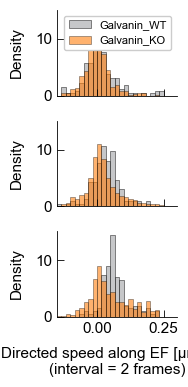

In [15]:

bins = np.linspace(-0.15, 0.25, 25)
E_field_values = sorted(df_intervals['E_V_cm'].unique())
celltypes = sorted(df_intervals['celltype'].unique())

fig, axs = plt.subplots(nrows=len(E_field_values), ncols=1, figsize=(2, 4), sharex=True, sharey=True)
if len(E_field_values) == 1:
    axs = [axs]

for idx, E in enumerate(E_field_values):
    ax = axs[idx]
    df_temp = df_intervals[df_intervals['E_V_cm'] == E]

    for celltype in reversed(celltypes):
        dot = []
        df_cell = df_temp[df_temp['celltype'] == celltype]

        for _, d in df_cell.groupby(['date', 'trial', 'user', 'cell', 'position']):
            d = d.sort_values('interval')
            if len(d) < 2:
                continue

            dx = np.diff(d['x'].values)
            mean_dx = np.mean(dx)
            directed_speed = mean_dx / (interval * 60.0)  # μm/sec 
            dot.append(directed_speed)

        if len(dot) > 0:
            alpha = 0.8 if celltype == 'Galvanin_WT' else 0.6
            ax.hist(dot, bins=bins, density=True, alpha=alpha,
                    edgecolor='black', linewidth=0.4,
                    label=celltype, color=color_dict.get(celltype, 'gray'))

    ax.set_xlim(-0.15, 0.3)
    if idx == 0:
        ax.legend(fontsize=8)

axs[-1].set_xlabel(f'Directed speed along EF [μm/min]\n(interval = {interval} frames)')
for ax in axs:
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()



In [24]:
high_speed_cells = df_mag_plot[df_mag_plot['mean_speed'] >= 1]
print(high_speed_cells[['date', 'trial', 'user', 'celltype', 'cell', 'mean_speed', 'E_V_cm']])

         date  trial user     celltype  cell  mean_speed  E_V_cm
1    20250403      0   NB  Galvanin_KO     1    2.026012       0
2    20250403      0   NB  Galvanin_KO     2    2.607741       0
4    20250403      0   NB  Galvanin_KO     4    1.604842       0
6    20250403      0   NB  Galvanin_KO     6    2.136342       0
7    20250403      0   NB  Galvanin_KO     7    2.940373       0
..        ...    ...  ...          ...   ...         ...     ...
800  20250411      1   AP  Galvanin_WT    18    1.795997       3
801  20250411      1   AP  Galvanin_WT    19    1.830389       3
802  20250411      1   AP  Galvanin_WT    22    1.778759       3
808  20250411      1   AP  Galvanin_WT    31    2.528652       3
809  20250411      1   AP  Galvanin_WT    39    1.764664       3

[330 rows x 7 columns]


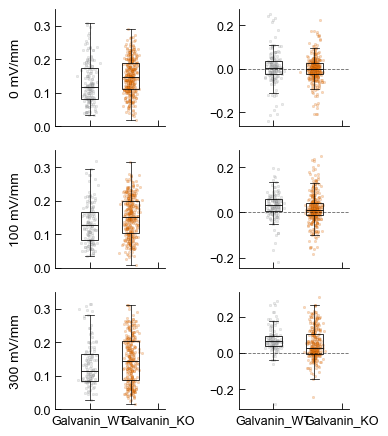

In [54]:

# Inputs: assumes df_mag_plot and df_proj_plot are already created
E_levels = sorted(df_mag_plot['E_V_cm'].unique())
celltypes = ['Galvanin_WT', 'Galvanin_KO']
colors = [color_dict[ct] for ct in celltypes]
celltype_color_dict = dict(zip(celltypes, colors))

# Layout: rows = E_levels, 2 columns (mag and proj)
fig, axs = plt.subplots(nrows=len(E_levels), ncols=2, figsize=(4, 1.5 * len(E_levels)), sharex='col')

# Plot settings
group_spacing = 0.9  # Unused in this version
dodge_offset = 0.25
jitter_scale = 0.05
box_width = 0.25

datasets = [df_mag_plot, df_proj_plot]
titles = ["average speed (μm/s)", "average speed along electric\nfield direction (μm/s)"]

for row_idx, E in enumerate(E_levels):
    for col_idx, (df_plot, ylabel) in enumerate(zip(datasets, titles)):
        ax = axs[row_idx, col_idx]
        # if row_idx == 0:
            # ax.set_title(ylabel, fontsize=10)

        for j, celltype in enumerate(celltypes):
            x_pos = j*0.6
            df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
            speeds = df_subset['mean_speed'].values

            if len(speeds) == 0:
                continue

            # Boxplot
            ax.boxplot(
                [speeds],
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showcaps=True,
                showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=.56),
                medianprops=dict(color='black', linewidth=0.6),
                whiskerprops=dict(color='black', linewidth=0.5),
                capprops=dict(color='black', linewidth=0.5),
            )

            # Scatter
            jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
            ax.scatter(
                jittered_x, speeds,
                s=4, color=celltype_color_dict[celltype],
                alpha=0.3, edgecolor='black', linewidth=0.1
            )

        # Y-axis limits
        if col_idx == 0:
            ax.set_ylim(0, 0.35)
            ax.set_yticks([0, 0.1, 0.2, 0.3])
        else:
            ax.axhline(0, color='black', linestyle='--', linewidth=0.6, alpha=0.6)
        #     ax.set_ylim(-0.075, 0.25)
        #     ax.set_yticks([0, 0.1, 0.2])

        # Labels
        if col_idx == 0:
            ax.set_ylabel(f"{E*100:.0f} mV/mm", fontsize=10)

        ax.set_xticks(range(len(celltypes)))
        ax.set_xticklabels(celltypes, fontsize=9)
        ax.tick_params(axis='y', labelsize=9)

        # Clean up spines
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        for spine in ['left', 'bottom']:
            ax.spines[spine].set_linewidth(0.6)
            ax.spines[spine].set_color('black')
        ax.tick_params(width=0.6, length=4)

# # Shared X label
# for ax in axs[-1, :]:
#     ax.set_xlabel("cell type", fontsize=10)

plt.tight_layout()

In [53]:
range(len(celltypes))


range(0, 2)

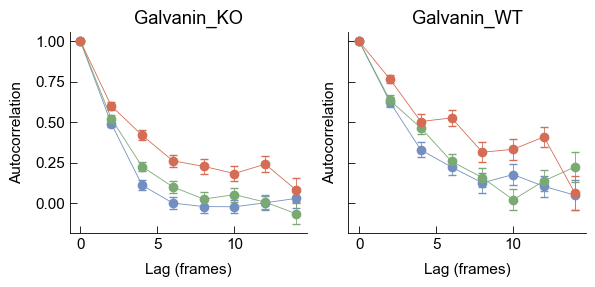

In [8]:
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr


autocorr_list = []
for g, d in df_intervals.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'position', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * 2,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()


celltypes = df_avg_autocorr.celltype.unique()
fig, axes = plt.subplots(1, len(celltypes), figsize=(3*len(celltypes),3), sharey=True)

if len(celltypes) == 1:
    axes = [axes]

for ax, celltype in zip(axes, celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype==celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]  # same across lags if consistent
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})", capsize=3, marker='o'
        )
    ax.set_title(celltype)
    ax.set_xlabel('Lag (frames)')
    ax.set_ylabel('Autocorrelation')
    # ax.legend()
plt.tight_layout()
plt.show()

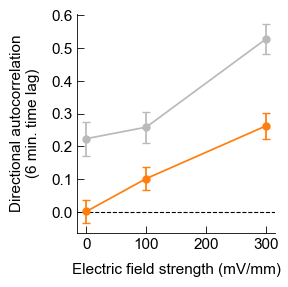

In [9]:
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr




autocorr_list = []
for g, d in df_intervals.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'position', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * 2,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()


lag_to_plot = 6  # in frames; 6-minute lag corresponds to lag=6 frames at 1-minute intervals

df_plot = df_avg_autocorr[df_avg_autocorr.lag == lag_to_plot]  # lag intervals are 3 frames each

fig, ax = plt.subplots(figsize=(3, 3))

for g, d in df_plot.groupby('celltype'):
    d_sorted = d.sort_values('E_V_cm')
    
    ax.errorbar(
        x=d_sorted.E_V_cm.values * 100,  # converting to mV/mm
        y=d_sorted.mean_autocorr,
        yerr=d_sorted.sem_autocorr,
        label=f"{g} (n={d_sorted.num_trajectories.values[0]})",
        marker='o', markersize=5, lw=1.25, capsize=3, zorder=10, color = color_dict[g]
    )

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=0)

# ax.set_xlim(-5, 350)
ax.set_xlabel('Electric field strength (mV/mm)')
ax.set_ylabel('Directional autocorrelation\n(6 min. time lag)')

# ax.legend(title='Cell type', bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)

plt.tight_layout()
plt.show()



/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_39943/554138232.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


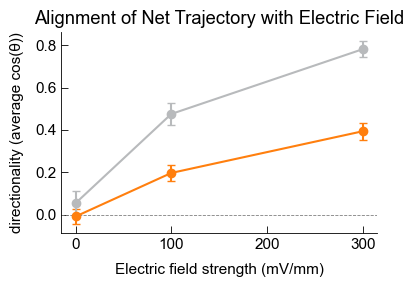

In [10]:
def calc_cos_theta_net_per_trajectory(df):
    def cos_theta_net(d):
        dx = d['x'].iloc[-1] - d['x'].iloc[0]
        dy = d['y'].iloc[-1] - d['y'].iloc[0]
        v = np.array([dx, dy])
        e_field = np.array([1, 0])
        norm = np.linalg.norm(v)
        if norm == 0:
            return np.nan
        return np.dot(v, e_field) / norm

    group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'user', 'position', 'cell']
    return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df_intervals)

df_cos_theta_avg = df_cos_theta_net_all.groupby(['celltype', 'E_V_cm']).agg(
    mean_cos_theta_net=('cos_theta_net', 'mean'),
    sem_cos_theta_net=('cos_theta_net', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index()

fig, ax = plt.subplots(figsize=(4,3))

for celltype, group in df_cos_theta_avg.groupby('celltype'):
    ax.errorbar(
        group['E_V_cm'] * 100,  # convert to mV/mm if needed
        group['mean_cos_theta_net'],
        yerr=group['sem_cos_theta_net'],
        label=celltype,
        marker='o',
        capsize=3,
        lw=1.5,
        color = color_dict[celltype]
    )

ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Electric field strength (mV/mm)')
ax.set_ylabel('directionality (average cos(θ))')
ax.set_title('Alignment of Net Trajectory with Electric Field')
# ax.legend(title='Cell type')
plt.tight_layout()
plt.show()

## Combined plots

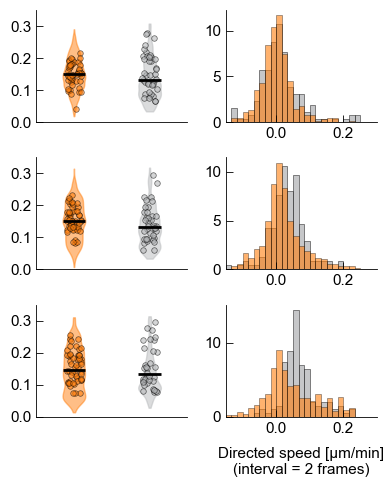

In [11]:


bins = np.linspace(-0.15, 0.25, 25)

# Create a grid: rows = E fields, 2 columns (left = violin, right = hist)
fig, axs = plt.subplots(
    nrows=len(E_field_values), ncols=2, figsize=(4, 5), sharex=False, sharey=False
)
if len(E_field_values) == 1:
    axs = [axs]  # ensure 2D indexing even with one row

# Loop through each field strength
for idx, E in enumerate(E_field_values):
    ax_violin = axs[idx][0]
    ax_hist = axs[idx][1]

    df_E = df_intervals[df_intervals.E_V_cm == E]

    # --- Left: 3D average speed plot ---
    for celltype in celltypes:
        df_ct = df_E[df_E.celltype == celltype]
        ind = celltype_dict[celltype]
        color = color_dict.get(celltype, 'gray')
        speed_all = []

        for (_, trial_group) in df_ct.groupby(['date', 'trial', 'user', 'position'], sort=False):
            speed_prep = []

            for _, d in trial_group.groupby('cell'):
                if len(d) <= 1:
                    continue

                d = d.sort_values('interval')
                use_z = 'z' in d.columns and not d['z'].isnull().all()
                pos_cols = ['x', 'y', 'z'] if use_z else ['x', 'y']
                pos = d[pos_cols].values
                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / (interval * 60.0)  # μm/sec

                if len(speeds) > 0:
                    speed_prep.append(np.mean(speeds))

            if len(speed_prep) > 0:
                jitter = np.random.uniform(-0.1, 0.1)
                x_pos = ind + jitter
                ax_violin.errorbar(
                    x_pos, np.mean(speed_prep),
                    marker='o', markersize=4, color=color,
                    markeredgecolor='k', markeredgewidth=0.5,
                    lw=0.5, alpha=0.6, zorder=5
                )
                speed_all.extend(speed_prep)

        if len(speed_all) > 0:
            vp = ax_violin.violinplot(
                speed_all, positions=[ind], points=60, widths=0.3,
                showmeans=False, showextrema=False, showmedians=False,
                bw_method=0.2
            )
            for pc in vp['bodies']:
                pc.set_color(color)
                pc.set_alpha(0.5)
                pc.set_zorder(0)

            ax_violin.hlines(np.mean(speed_all), ind - 0.15, ind + 0.15,
                             color='k', lw=2, zorder=10)

        ax_violin.set_xlim(-0.5, len(celltypes) - 0.5)
        ax_violin.set_ylim(0, 0.35)
        ax_violin.set_yticks([0.0, 0.1, 0.2, 0.3])
        # ax_violin.set_ylabel('avg. speed\n' + r'($\mu$m/s)')
        ax_violin.xaxis.set_visible(False)

    # --- Right: Directed speed histograms ---
    for celltype in reversed(celltypes):
        dot = []
        df_cell = df_E[df_E.celltype == celltype]

        for _, d in df_cell.groupby(['date', 'trial', 'user', 'cell', 'position']):
            d = d.sort_values('interval')
            if len(d) < 2:
                continue

            dx = np.diff(d['x'].values)
            mean_dx = np.mean(dx)
            directed_speed = mean_dx / (interval * 60.0)  # μm/sec
            dot.append(directed_speed) 

        if len(dot) > 0:
            alpha = 0.8 if celltype == 'Galvanin_WT' else 0.6
            ax_hist.hist(dot, bins=bins, density=True, alpha=alpha,
                         edgecolor='black', linewidth=0.4,
                         label=celltype, color=color_dict.get(celltype, 'gray'))

    ax_hist.set_xlim(-0.15, 0.3)
    if idx == len(E_field_values) - 1:
        ax_hist.set_xlabel(f'Directed speed [μm/min]\n(interval = {interval} frames)')
    # ax_hist.set_ylabel('Density')

    # if idx == 0:
        # ax_hist.legend(fontsize=8, loc='upper right')


plt.tight_layout()
plt.show()

fig.savefig('../../figures/Figure3_zebrafish_speed.pdf', bbox_inches='tight')


/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_13032/745666704.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


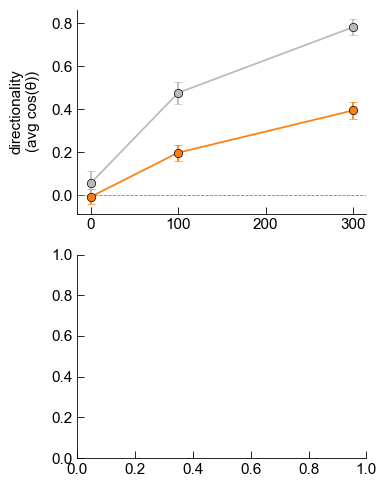

In [70]:

# -- Top Plot: Net Cos(θ) --

def calc_cos_theta_net_per_trajectory(df):
    def cos_theta_net(d):
        dx = d['x'].iloc[-1] - d['x'].iloc[0]
        dy = d['y'].iloc[-1] - d['y'].iloc[0]
        v = np.array([dx, dy])
        e_field = np.array([1, 0])
        norm = np.linalg.norm(v)
        if norm == 0:
            return np.nan
        return np.dot(v, e_field) / norm

    group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'user', 'position', 'cell']
    return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')

df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df_intervals)

df_cos_theta_avg = df_cos_theta_net_all.groupby(['celltype', 'E_V_cm']).agg(
    mean_cos_theta_net=('cos_theta_net', 'mean'),
    sem_cos_theta_net=('cos_theta_net', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index()

# -- Bottom Plot: Directional Autocorrelation (6 min lag) --

def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr

autocorr_list = []
for g, d in df_intervals.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'position', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)
    angles = np.arctan2(vectors[:, 1], vectors[:, 0])
    cos_angles = np.cos(angles)
    acf = non_overlapping_normalized_autocorrelation(cos_angles)
    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * interval,  # scale lag by sampling interval
        'autocorr': acf
    }))

df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()

lag_to_plot = 6  # 6-minute lag scaled to intervals (e.g., 6 min = 6 if 1-min intervals)
df_plot = df_avg_autocorr[df_avg_autocorr.lag == lag_to_plot]

# -- Create Figure with Two Rows --
fig, axs = plt.subplots(2, 1, figsize=(4, 5), sharex=False)

# Top plot: net directionality
ax_top = axs[0]
for celltype, group in df_cos_theta_avg.groupby('celltype'):
    ax_top.errorbar(
        group['E_V_cm'] * 100,  # V/cm to mV/mm
        group['mean_cos_theta_net'],
        yerr=group['sem_cos_theta_net'],
        label=celltype,
        marker='o',
        capsize=3,
        markersize=6,
        lw=1.25,
        color=color_dict[celltype],
        markeredgecolor='k',
        markeredgewidth=0.5
    )
ax_top.axhline(0, color='gray', linestyle='--')
ax_top.set_ylabel('directionality\n(avg cos(θ))')

# # Bottom plot: directional autocorrelation at 6-min lag
# ax_bottom = axs[1]
# for celltype, d in df_plot.groupby('celltype'):
#     d_sorted = d.sort_values('E_V_cm')
#     ax_bottom.errorbar(
#         x=d_sorted.E_V_cm.values * 100,
#         y=d_sorted.mean_autocorr,
#         yerr=d_sorted.sem_autocorr,
#         label=f"{celltype} (n={d_sorted.num_trajectories.values[0]})",
#         marker='o',
#         markersize=5,
#         lw=1.25,
#         capsize=3,
#         zorder=10,
#         color=color_dict[celltype]
#     )

# ax_bottom.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=0)
# ax_bottom.set_xlabel('Electric field strength (mV/mm)')
# ax_bottom.set_ylabel('autocorr (6 min lag)')


plt.tight_layout()
plt.show()

fig.savefig('../../figures/Figure3_zebrafish_cosinetheta.pdf', bbox_inches='tight')


In [69]:
from scipy.stats import mannwhitneyu
import pandas as pd

# Define cell types
celltypes = df_intervals.celltype.unique() #['EL4 WT', 'EL4 KO12']

# --- Cos(θ) net statistics ---
def perform_mannwhitney_cos_theta(df):
    results = []
    for ev in sorted(df['E_V_cm'].unique()):
        subset = df[df['E_V_cm'] == ev]
        group1 = subset[subset['celltype'] == celltypes[0]]['cos_theta_net'].dropna()
        group2 = subset[subset['celltype'] == celltypes[1]]['cos_theta_net'].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
            results.append({'E_V_cm': ev, 'statistic': stat, 'p_value': p, 'metric': 'cos_theta_net'})
    return pd.DataFrame(results)

# --- Autocorrelation statistics (only at lag = 6) ---
def perform_mannwhitney_autocorr(df):
    df_lag6 = df[df['lag'] == 6]
    results = []
    for ev in sorted(df_lag6['E_V_cm'].unique()):
        subset = df_lag6[df_lag6['E_V_cm'] == ev]
        group1 = subset[subset['celltype'] == celltypes[0]]['autocorr'].dropna()
        group2 = subset[subset['celltype'] == celltypes[1]]['autocorr'].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
            results.append({'E_V_cm': ev, 'statistic': stat, 'p_value': p, 'metric': 'autocorr'})
    return pd.DataFrame(results)

# Run both tests
df_stats_cos = perform_mannwhitney_cos_theta(df_cos_theta_net_all)
df_stats_autocorr = perform_mannwhitney_autocorr(df_autocorr)

# Combine
df_stats_summary = pd.concat([df_stats_cos, df_stats_autocorr], ignore_index=True)

# Optional: print or export
print(df_stats_summary)
# df_stats_summary.to_csv("mannwhitney_results.csv", index=False)

5.371682e-04 

   E_V_cm  statistic       p_value         metric
0       0    28723.0  3.095898e-01  cos_theta_net
1       1    19530.0  2.150614e-05  cos_theta_net
2       3    12857.5  1.159970e-08  cos_theta_net
3       0    22290.5  3.785280e-04       autocorr
4       1    21722.0  2.861035e-02       autocorr
5       3    14218.5  5.371682e-04       autocorr


0.0005371682

## Statistics

In [13]:
interval = 2
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)


# Prepare output for review
E_field_values = sorted(df_intervals['E_V_cm'].unique())

for E in E_field_values:
    df_E = df_intervals[df_intervals.E_V_cm == E]

    # Initialize containers
    grouped_speeds = {
        'Galvanin_WT': [],
        'Galvanin_KO': []
    }

    for celltype in grouped_speeds.keys():
        df_ct = df_E[df_E.celltype == celltype]
        speed_per_trial = []

        for _, trial_df in df_ct.groupby(['date', 'trial', 'user', 'position'], sort=False):
            speed_per_cell = []

            for _, d in trial_df.groupby('cell'):
                d = d.sort_values('interval')
                if len(d) <= 1:
                    continue

                # Choose 2D or 3D based on z column presence
                use_z = 'z' in d.columns and not d['z'].isnull().any()
                pos = d[['x', 'y', 'z']].values if use_z else d[['x', 'y']].values

                dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)
                speeds = dists / (interval * 60.0)  # μm/sec

                if len(speeds) > 0:
                    speed_per_cell.append(np.mean(speeds))

            if len(speed_per_cell) > 0:
                trial_mean = np.mean(speed_per_cell)
                speed_per_trial.append(trial_mean)

        grouped_speeds[celltype] = speed_per_trial

    # Perform statistical comparisons
    print(f"\n{E} V/cm average speed comparisons:")

    try:
        res = mannwhitneyu(grouped_speeds['Galvanin_WT'], grouped_speeds['Galvanin_KO'], alternative='two-sided')
        print(f"  KO vs WT: U={res.statistic:.1f}, p={res.pvalue:.3g}, n={len(grouped_speeds['Galvanin_WT'])} vs {len(grouped_speeds['Galvanin_KO'])}")
    except ValueError:
        print("  KO vs WT: insufficient data")




0 V/cm average speed comparisons:
  KO vs WT: U=1036.0, p=0.944, n=41 vs 51

1 V/cm average speed comparisons:
  KO vs WT: U=800.0, p=0.126, n=38 vs 52

3 V/cm average speed comparisons:
  KO vs WT: U=789.0, p=0.365, n=35 vs 51


In [14]:
interval = 2
df_intervals = parse_trajectories(df_filtered_tracks, frame_step=interval)


# Get unique field strengths
E_field_values = sorted(df_intervals['E_V_cm'].unique())

# For each E field, compute and compare dx-derived directed speeds
for E in E_field_values:
    df_E = df_intervals[df_intervals.E_V_cm == E]

    dx_speeds = {
        'Galvanin_WT': [],
        'Galvanin_KO': []
    }

    for celltype in dx_speeds.keys():
        df_ct = df_E[df_E.celltype == celltype]

        for _, d in df_ct.groupby(['date', 'trial', 'user', 'cell', 'position']):
            d = d.sort_values('interval')
            if len(d) < 2:
                continue

            dx = np.diff(d['x'].values)
            dx_speed = dx / (interval * 60.0)  # μm/sec
            dx_speeds[celltype].extend(dx_speed)

    # --- Perform statistical tests ---
    print(f"\n{E} V/cm directed speed comparisons:")

    try:
        res = mannwhitneyu(dx_speeds['Galvanin_WT'], dx_speeds['Galvanin_KO'], alternative='two-sided')
        print(f"  KO vs WT: U={res.statistic:.1f}, p={res.pvalue:.3g}, n={len(dx_speeds['Galvanin_WT'])} vs {len(dx_speeds['Galvanin_KO'])}")
    except ValueError:
        print("  KO vs WT: insufficient data")

 


0 V/cm directed speed comparisons:
  KO vs WT: U=4979010.0, p=0.00155, n=2042 vs 4651

1 V/cm directed speed comparisons:
  KO vs WT: U=4631265.0, p=3.75e-08, n=1900 vs 4485

3 V/cm directed speed comparisons:
  KO vs WT: U=3436064.0, p=1.93e-15, n=1607 vs 3762


In [15]:
# Create a new global unique cell ID per group
df_intervals['cell_global'] = (
    df_intervals['celltype'].astype(str) + '_' +
    df_intervals['date'].astype(str) + '_' +
    df_intervals['trial'].astype(str) + '_' +
    df_intervals['user'].astype(str) + '_' +
    df_intervals['position'].astype(str) + '_' +
    df_intervals['cell'].astype(str)
)

# Group and count
summary_stats = []
for (celltype, E_V_cm), df_group in df_intervals.groupby(['celltype', 'E_V_cm']):
    n_samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    n_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': n_samples,
        'n_cells': n_cells
    })

df_summary_stats = pd.DataFrame(summary_stats).sort_values(['celltype', 'E_V_cm'])
df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,Galvanin_KO,0,4,373
1,Galvanin_KO,1,4,358
2,Galvanin_KO,3,4,313
3,Galvanin_WT,0,4,163
4,Galvanin_WT,1,4,144
5,Galvanin_WT,3,4,126


In [16]:
# Create a new global unique cell ID per group
df_intervals['cell_global'] = (
    df_intervals['celltype'].astype(str) + '_' +
    df_intervals['date'].astype(str) + '_' +
    df_intervals['trial'].astype(str) + '_' +
    df_intervals['user'].astype(str) + '_' +
    df_intervals['position'].astype(str) + '_' +
    df_intervals['cell'].astype(str)
)

# Group and count
summary_stats = []
for (celltype, E_V_cm), df_group in df_intervals.groupby(['celltype', 'E_V_cm']):
    n_samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    n_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': n_samples,
        'n_cells': n_cells
    })

df_summary_stats = pd.DataFrame(summary_stats).sort_values(['celltype', 'E_V_cm'])
df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,Galvanin_KO,0,4,373
1,Galvanin_KO,1,4,358
2,Galvanin_KO,3,4,313
3,Galvanin_WT,0,4,163
4,Galvanin_WT,1,4,144
5,Galvanin_WT,3,4,126


In [23]:
import numpy as np
import pandas as pd

def dot_projection_autocorrelation(df, interval=3, e_field_vector=np.array([1, 0])):
    """
    Compute non-overlapping autocorrelation of dot products between velocity and electric field vectors.

    Parameters:
    - df: pandas DataFrame with x, y, 'interval' columns, grouped per trajectory
    - interval: number of frames between measurements (used to convert to time)
    - e_field_vector: direction of the electric field as a numpy array

    Returns:
    - DataFrame with lag, autocorrelation, and associated metadata
    """
    def non_overlapping_autocorr(signal):
        n = len(signal)
        max_lag = n // 2
        autocorr = np.zeros(max_lag + 1)
        for lag in range(max_lag + 1):
            indices = np.arange(0, n - lag, lag + 1)
            pairs_a, pairs_b = signal[indices], signal[indices + lag]
            norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
            autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
        return autocorr

    results = []

    # Group by unique trajectory
    group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'user', 'position','cell']
    for g, d in df.groupby(group_cols):
        d = d.sort_values('interval')
        positions = d[['x', 'y']].values
        if len(positions) < 3:
            continue

        velocities = np.diff(positions, axis=0) / (interval * 60.0)  # in μm/sec
        dot_series = np.dot(velocities, e_field_vector)

        acf = non_overlapping_autocorr(dot_series)
        lag_frames = np.arange(len(acf)) * interval

        results.append(pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'position':g[5],
            'cell': g[6],
            'lag': lag_frames,
            'dot_autocorr': acf
        }))

    return pd.concat(results, ignore_index=True)

In [24]:
df_dot_autocorr = dot_projection_autocorrelation(df_intervals, interval=3)

# Aggregate
df_dot_avg = df_dot_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('dot_autocorr', 'mean'),
    sem_autocorr=('dot_autocorr', lambda x: np.std(x, ddof=1)/np.sqrt(len(x))),
    num_trajectories=('dot_autocorr', 'count')
).reset_index()

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_dot_autocorrelation(df_dot_avg, interval=3, color_dict=None):
    """
    Plot mean dot-product-based autocorrelation vs. lag time.

    Parameters:
    - df_dot_avg: DataFrame with ['celltype', 'E_V_cm', 'lag', 'mean_autocorr', 'sem_autocorr']
    - interval: frame step used to calculate lag in minutes
    - color_dict: optional dict mapping celltype to color
    """
    celltypes = df_dot_avg['celltype'].unique()
    field_strengths = sorted(df_dot_avg['E_V_cm'].unique())
    fig, axes = plt.subplots(1, len(celltypes), figsize=(4 * len(celltypes), 3), sharey=True)

    if len(celltypes) == 1:
        axes = [axes]

    for ax, celltype in zip(axes, celltypes):
        df_ct = df_dot_avg[df_dot_avg['celltype'] == celltype]

        for E in field_strengths:
            df_E = df_ct[df_ct['E_V_cm'] == E]
            color = color_dict[celltype] if color_dict and celltype in color_dict else None

            ax.errorbar(
                x=df_E['lag'] * interval,  # convert frame lags to minutes
                y=df_E['mean_autocorr'],
                yerr=df_E['sem_autocorr'],
                label=f"{E} V/cm",
                capsize=3,
                marker='o',
                lw=1.5,
                color=color
            )

        ax.axhline(0, color='gray', linestyle='--', lw=0.8)
        ax.set_title(f"{celltype}")
        ax.set_xlabel("Lag (minutes)")
        ax.set_ylim(-0.1, 1.05)

    axes[0].set_ylabel("Autocorrelation of EF-projected velocity")
    axes[-1].legend(title="E field", loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

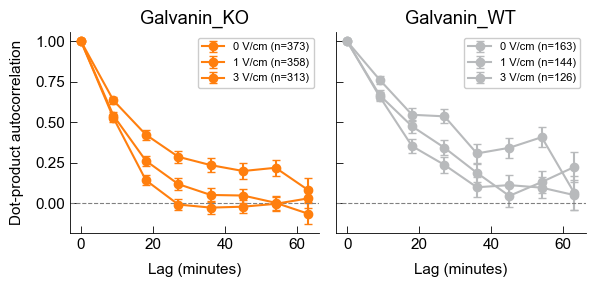

In [45]:
df_dot_autocorr = dot_projection_autocorrelation(df_intervals, interval=3)
df_dot_avg = df_dot_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('dot_autocorr', 'mean'),
    sem_autocorr=('dot_autocorr', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
    num_trajectories=('dot_autocorr', 'count')
).reset_index()

plot_dot_autocorrelation(df_dot_avg, interval=3, color_dict=color_dict)

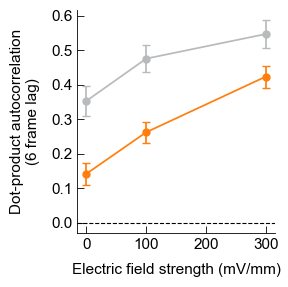

In [32]:
lag_to_plot = 6  # lag in frames

# Filter to the desired lag
df_plot = df_dot_avg[df_dot_avg.lag == lag_to_plot]

# Plot
fig, ax = plt.subplots(figsize=(3, 3))

for g, d in df_plot.groupby('celltype'):
    d_sorted = d.sort_values('E_V_cm')

    ax.errorbar(
        x=d_sorted.E_V_cm.values * 100,  # convert to mV/mm
        y=d_sorted.mean_autocorr,
        yerr=d_sorted.sem_autocorr,
        label=f"{g} (n={d_sorted.num_trajectories.values[0]})",
        marker='o', markersize=5, lw=1.25, capsize=3,
        zorder=10, color=color_dict.get(g, 'gray')
    )

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, zorder=0)

ax.set_xlabel('Electric field strength (mV/mm)')
ax.set_ylabel(f'Dot-product autocorrelation\n({lag_to_plot} frame lag)')

# ax.legend(title='Cell type', bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)
plt.tight_layout()
plt.show()

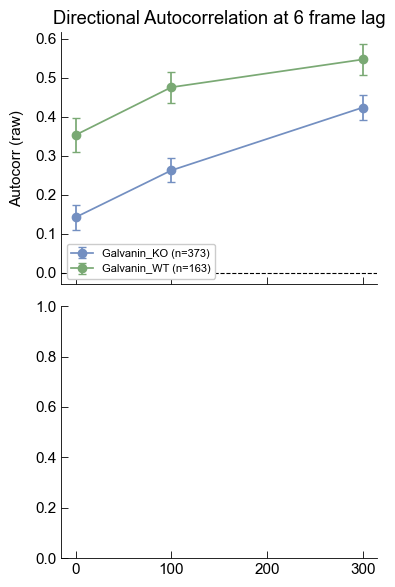

In [44]:
import matplotlib.pyplot as plt

# Define lag to plot (e.g., 6-minute lag, so lag=6)
lag_to_plot = 6

# Subset for the chosen lag
df_plot = df_dot_avg[df_dot_avg['lag'] == lag_to_plot].copy()

# Compute baseline (0 V/cm) autocorrelation per celltype
baseline = df_plot[df_plot['E_V_cm'] == 0.0].set_index('celltype')['mean_autocorr'].to_dict()

# Create corrected autocorrelation column
df_plot['corrected_autocorr'] = df_plot.apply(
    lambda row: row['mean_autocorr'] - baseline.get(row['celltype'], 0), axis=1
)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 6), sharex=True)

for g, d in df_plot.groupby('celltype'):
    d_sorted = d.sort_values('E_V_cm')
    ax1.errorbar(
        d_sorted.E_V_cm.values * 100,
        d_sorted.mean_autocorr,
        yerr=d_sorted.sem_autocorr,
        label=f"{g} (n={d_sorted.num_trajectories.values[0]})",
        marker='o', lw=1.25, capsize=3
    )
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Autocorr (raw)')
ax1.set_title(f'Directional Autocorrelation at {lag_to_plot} frame lag')

# for g, d in df_plot.groupby('celltype'):
#     d_sorted = d.sort_values('E_V_cm')
#     ax2.errorbar(
#         d_sorted.E_V_cm.values * 100,
#         d_sorted.corrected_autocorr,
#         yerr=d_sorted.sem_autocorr,
#         label=f"{g} (n={d_sorted.num_trajectories.values[0]})",
#         marker='o', lw=1.25, capsize=3
#     )
# ax2.axhline(0, color='k', linestyle='--', linewidth=0.8)
# ax2.set_xlabel('Electric field strength (mV/mm)')
# ax2.set_ylabel('Bias above 0 V/cm')
# ax2.set_title('Corrected EF-Directed Bias')

ax1.legend(fontsize=8)
plt.tight_layout()
plt.show()

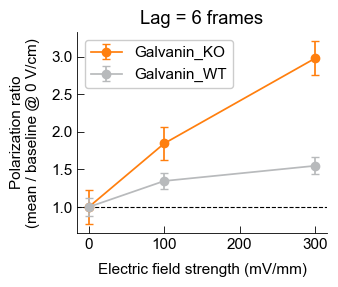

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select lag to plot
lag_to_plot = 6  # frames (or 6 min if 1 frame = 1 min)

# Filter for selected lag
df_plot = df_dot_avg[df_dot_avg.lag == lag_to_plot].copy()

# Get baseline autocorrelation at 0 V/cm for each celltype
baseline = df_plot[df_plot.E_V_cm == 0].set_index('celltype')['mean_autocorr'].to_dict()

# # --- 1. Corrected Autocorrelation Plot ---
# fig1, ax1 = plt.subplots(figsize=(3.5, 3))

# for celltype, group in df_plot.groupby('celltype'):
#     baseline_val = baseline.get(celltype, np.nan)
#     if pd.isna(baseline_val):
#         continue  # skip if baseline missing

#     d_sorted = group.sort_values('E_V_cm')
#     corrected = d_sorted['mean_autocorr'] - baseline_val

#     ax1.errorbar(
#         d_sorted.E_V_cm * 100,  # convert to mV/mm
#         corrected,
#         yerr=d_sorted.sem_autocorr,  # keep SEM as is
#         label=celltype,
#         marker='o', capsize=3, lw=1.25,
#         color=color_dict.get(celltype, 'gray')
#     )

# ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
# ax1.set_xlabel('Electric field strength (mV/mm)')
# ax1.set_ylabel('Corrected directional autocorr.\n(baseline at 0 V/cm subtracted)')
# ax1.set_title(f'Lag = {lag_to_plot} frames')
# ax1.legend()
# plt.tight_layout()
# plt.show()

# --- 2. Polarization Ratio Plot ---
fig2, ax2 = plt.subplots(figsize=(3.5, 3))

for celltype, group in df_plot.groupby('celltype'):
    baseline_val = baseline.get(celltype, np.nan)
    if pd.isna(baseline_val) or baseline_val == 0:
        continue

    d_sorted = group.sort_values('E_V_cm')
    ratio = d_sorted['mean_autocorr'] / baseline_val

    ax2.errorbar(
        d_sorted.E_V_cm * 100,
        ratio,
        yerr=d_sorted.sem_autocorr / abs(baseline_val),
        label=celltype,
        marker='o', capsize=3, lw=1.25,
        color=color_dict.get(celltype, 'gray')
    )

ax2.axhline(1, color='k', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Electric field strength (mV/mm)')
ax2.set_ylabel('Polarization ratio\n(mean / baseline @ 0 V/cm)')
ax2.set_title(f'Lag = {lag_to_plot} frames')
ax2.legend()
plt.tight_layout()
plt.show()